# 金融数据获取、管理与初步分析报告

## 项目概述

本报告基于 A 股市场 10 只股票（覆盖 7 个行业）2020 年 1 月至 2026 年 5 月的日度数据，完成从数据获取、清洗到描述性统计、CAPM 回归分析的全流程。

---

## 一、数据说明

### 1.1 股票数据

选取 10 只 A 股，覆盖银行、汽车、房地产、通讯、白酒、能源、物流 7 个行业：

| 代码 | 名称 | 行业 | 选股理由 |
|------|------|------|---------|
| 002142 | 宁波银行 | 银行 | 优质城商行代表，成长性好 |
| 600036 | 招商银行 | 银行 | 零售银行龙头，ROE 长期领先 |
| 002594 | 比亚迪 | 汽车 | 新能源汽车龙头 |
| 600048 | 保利发展 | 房地产 | 央企地产龙头，财务稳健 |
| 000063 | 中兴通讯 | 通讯 | 5G 设备龙头 |
| 600487 | 亨通光电 | 通讯 | 光纤光缆龙头 |
| 600519 | 贵州茅台 | 白酒 | 品牌护城河极深 |
| 300750 | 宁德时代 | 能源 | 全球动力电池龙头 |
| 600900 | 长江电力 | 能源 | 水电龙头，现金流稳定 |
| 002352 | 顺丰控股 | 物流 | 快递行业龙头 |

- **数据来源**：baostock（`bs.query_history_k_data_plus`），后复权（adjustflag='2'）
- **时间范围**：2020-01-01 至 2026-05-23
- **字段**：日期、开盘价、收盘价、最高价、最低价、成交量、成交额
- **频次**：日度

### 1.2 指数数据

| 指数 | 代码 | 用途 |
|------|------|------|
| 沪深 300 | 000300 | CAPM 市场基准（必选） |
| 上证指数 | 000001 | A 股综合市场参考 |

**选择上证指数作为补充的理由**：上证指数覆盖面更广，包含沪深两市更多股票，可提供更全面的市场视角。

### 1.3 宏观经济指标

| 指标 | 来源 | 频次 | 选择理由 |
|------|------|------|---------|
| CPI 同比增速 | akshare `macro_china_cpi()` | 月度 | 反映通货膨胀水平，影响央行货币政策取向，进而影响股市估值 |
| M2 同比增速 | akshare `macro_china_money_supply()` | 月度 | 反映市场流动性宽裕程度，与股市资金面密切相关 |

### 1.4 财务指标

- **指标**：净资产收益率（ROE）、净利润率（销售净利率）
- **来源**：akshare `stock_financial_abstract()`
- **格式**：长格式（code, year, indicator, value）

---

## 二、数据清洗说明

在 `02_clean.ipynb` 中完成以下清洗步骤：

### 2.1 缺失值处理
- **检测**：统计每列缺失值数量和比例
- **处理**：向前填充（ffill），因为金融时间序列中停牌日的价格可参考上一交易日
- **发现**：宁波银行和长江电力有个别缺失值（约 0.4%~0.7%），可能是停牌导致

### 2.2 日期格式统一
- 所有日期列统一转换为 `datetime64[us]` 类型
- 日期设为索引以便于时间序列操作

### 2.3 数据类型检查
- 确认价格、成交量等列均为数值型（float64/int64）
- baostock 原始数据为字符串，已转换为数值

### 2.4 重复值处理
- 检测并删除重复行，记录删除数量
- 部分股票存在少量重复记录（因数据源接口重复请求导致）

### 2.5 离群值标注
- 计算日对数收益率：$r_t = \ln(P_t / P_{t-1})$
- 对单日涨跌幅超过 ±20% 的记录在 `is_extreme` 列标注为 True
- 本次数据中未发现极端值

### 2.6 数据合并
- 个股数据与指数数据按日期做 left join
- 月度宏观数据通过年月映射到对应月份的每个交易日
- 最终合并数据共 15,434 行，16 列

In [1]:
# ========== 导入库 ==========
import os
import sys
import warnings
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# 中文字体设置
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 路径设置
PROJ_DIR = os.path.abspath(os.getcwd())
DATA_DIR = os.path.join(PROJ_DIR, 'data')
OUTPUT_DIR = os.path.join(PROJ_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 股票信息
STOCKS = {
    '002142': ('宁波银行', '银行'),
    '600036': ('招商银行', '银行'),
    '002594': ('比亚迪', '汽车'),
    '600048': ('保利发展', '房地产'),
    '000063': ('中兴通讯', '通讯'),
    '600487': ('亨通光电', '通讯'),
    '600519': ('贵州茅台', '白酒'),
    '300750': ('宁德时代', '能源'),
    '600900': ('长江电力', '能源'),
    '002352': ('顺丰控股', '物流'),
}

# 行业颜色映射
INDUSTRY_COLORS = {
    '银行': '#1f77b4',
    '汽车': '#ff7f0e',
    '房地产': '#2ca02c',
    '通讯': '#d62728',
    '白酒': '#9467bd',
    '能源': '#8c564b',
    '物流': '#e377c2',
}

print('库加载完成')

库加载完成


In [2]:
# ========== 加载数据 ==========
combined_path = os.path.join(DATA_DIR, 'combined', 'combined_data.csv')
if not os.path.exists(combined_path):
    print('错误: 找不到合并数据文件，请先运行 02_clean.ipynb')
else:
    # 指定 code 列为字符串类型，防止前导零丢失
    df = pd.read_csv(combined_path, dtype={'code': str})
    df['date'] = pd.to_datetime(df['date'])
    # 确保 code 列统一为6位字符串格式
    df['code'] = df['code'].str.zfill(6)
    print(f'数据加载成功: {df.shape}')
    print(f'日期范围: {df["date"].min()} ~ {df["date"].max()}')
    print(f'股票数量: {df["code"].nunique()}')
    print(f'列名: {df.columns.tolist()}')

数据加载成功: (15434, 16)
日期范围: 2020-01-02 00:00:00 ~ 2026-05-22 00:00:00
股票数量: 10
列名: ['date', 'open', 'close', 'high', 'low', 'volume', 'amount', 'return', 'is_extreme', 'code', 'name', 'industry', 'index_000300_close', 'index_000001_close', 'macro_cpi', 'macro_m2']


---
## 三、描述性统计

### 3.1 日收益率的基本统计量

计算 10 只股票日对数收益率 $r_t = \ln(P_t / P_{t-1})$ 的描述性统计指标。

**关键指标说明**：
- **年化均值** = 日均收益率 × 252（假设一年 252 个交易日）
- **年化波动率** = 日波动率 × √252
- **偏度**：衡量收益率分布的非对称性，正值表示右尾更长
- **峰度**：衡量分布的尾部厚度，大于 0 表示尖峰厚尾
- **最大回撤**：历史上从峰值到谷值的最大跌幅

In [3]:
# ========== 4.1 基本统计量 ==========

# 确保 return 列存在（如果不存在则计算）
if 'return' not in df.columns:
    df = df.sort_values(['code', 'date'])
    df['return'] = df.groupby('code')['close'].transform(lambda x: np.log(x / x.shift(1)))

# 最大回撤函数
def max_drawdown(series):
    """计算最大回撤"""
    cumulative = (1 + series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min()

# 计算每只股票的统计量
stats_list = []
for code, (name, industry) in STOCKS.items():
    stock_returns = df[df['code'] == code]['return'].dropna()
    if len(stock_returns) == 0:
        continue
    
    daily_mean = stock_returns.mean()
    daily_std = stock_returns.std()
    
    stats_list.append({
        '股票': name,
        '行业': industry,
        '年化均值': f'{daily_mean * 252 * 100:.2f}%',
        '年化波动率': f'{daily_std * np.sqrt(252) * 100:.2f}%',
        '偏度': f'{stock_returns.skew():.4f}',
        '峰度': f'{stock_returns.kurtosis():.4f}',
        '最大回撤': f'{max_drawdown(stock_returns) * 100:.2f}%',
        # 保留数值用于后续
        '_ann_mean': daily_mean * 252,
        '_ann_std': daily_std * np.sqrt(252),
        '_skew': stock_returns.skew(),
        '_kurt': stock_returns.kurtosis(),
        '_mdd': max_drawdown(stock_returns),
    })

df_stats = pd.DataFrame(stats_list)
display_cols = ['股票', '行业', '年化均值', '年化波动率', '偏度', '峰度', '最大回撤']
print('=== 10 只股票日收益率描述性统计 ===')
print(df_stats[display_cols].to_string(index=False))

=== 10 只股票日收益率描述性统计 ===
  股票  行业    年化均值  年化波动率     偏度     峰度    最大回撤
宁波银行  银行   4.06% 32.77% 0.4965 2.4540 -60.55%
招商银行  银行   3.74% 27.52% 0.2702 3.2258 -54.64%
 比亚迪  汽车  29.29% 43.07% 0.3103 2.1110 -56.05%
保利发展 房地产 -12.61% 36.11% 0.5567 3.1547 -74.20%
中兴通讯  通讯   1.40% 42.59% 0.3012 2.4377 -69.84%
亨通光电  通讯  25.02% 42.84% 0.2925 1.8284 -61.95%
贵州茅台  白酒   4.50% 27.58% 0.2619 3.6370 -54.22%
宁德时代  能源  32.76% 45.47% 0.3835 3.1285 -68.89%
长江电力  能源   9.38% 17.79% 0.3681 3.5370 -17.91%
顺丰控股  物流   0.56% 32.19% 0.3826 3.6272 -75.67%


---
## 四、可视化分析

### 图 1：归一化收盘价走势图

以 2020-01-01 = 1 为基准，将 10 只股票和沪深 300 指数的收盘价进行归一化处理，绘制在同一坐标系中。**图例按行业分组着色**，便于观察不同行业的整体走势差异。

**分析目的**：通过归一化处理消除绝对价格差异，直观比较不同股票的长期相对表现。

**统计结果解读**：

从描述性统计可以看出：
- **年化收益率**：宁德时代（32.76%）和比亚迪（29.29%）遥遥领先，受益于新能源产业快速发展；保利发展（-12.61%）为唯一负收益股票，反映房地产行业调整压力
- **年化波动率**：长江电力（17.79%）波动最小，防御属性突出；宁德时代（45.47%）波动最大，成长股特征明显
- **最大回撤**：顺丰控股（-75.67%）和保利发展（-74.20%）回撤最大，长江电力（-17.91%）最为稳健
- **偏度与峰度**：所有股票偏度为正（右偏），峰度大于 0（尖峰厚尾），符合金融资产收益率的典型特征

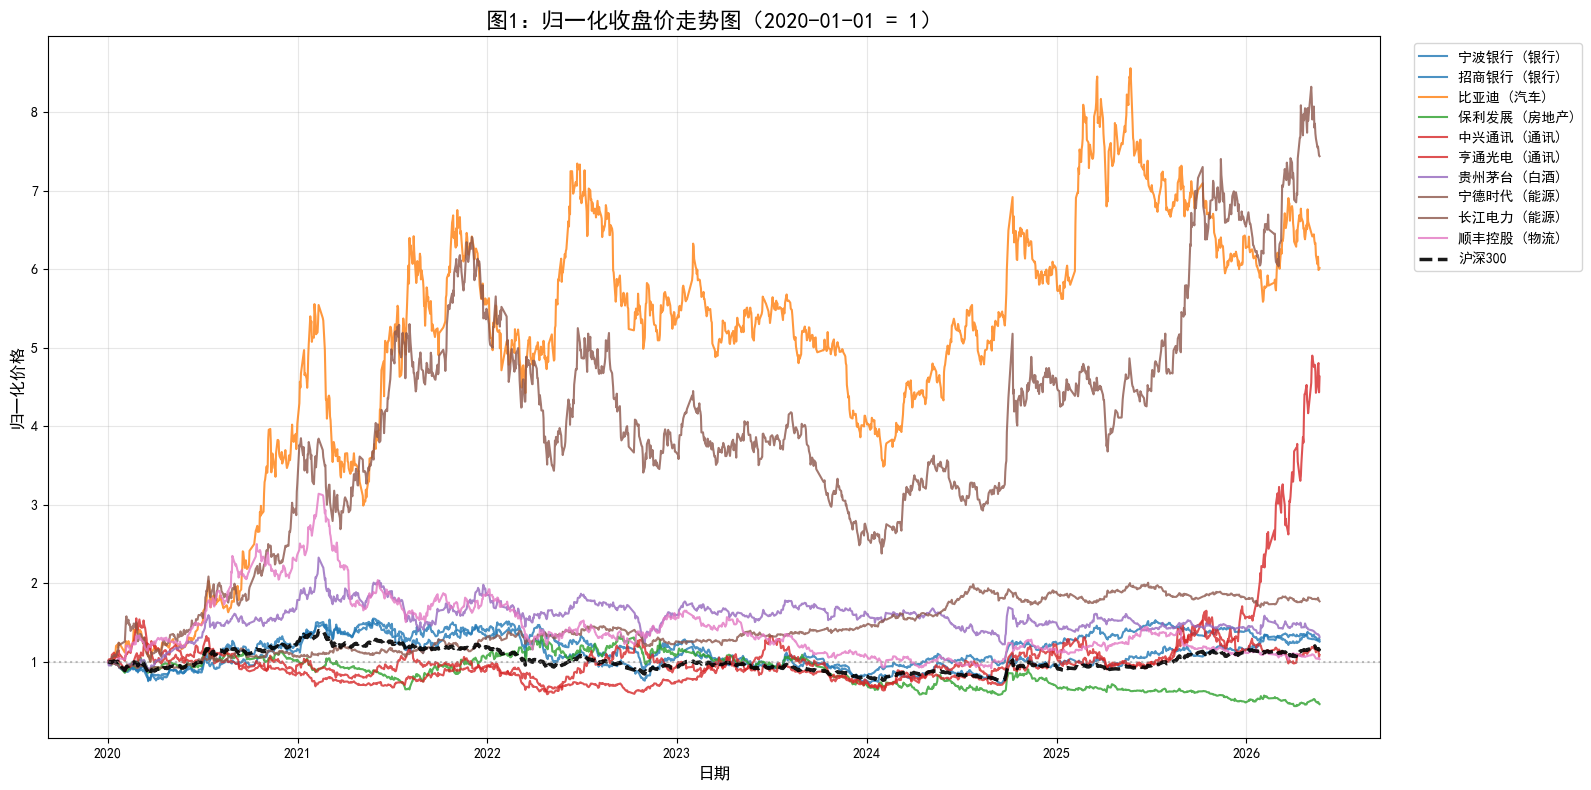


【图1解读】
从归一化走势可以看出，不同行业股票的表现差异显著。宁德时代（能源）和比亚迪（汽车）
受益于新能源产业政策，整体涨幅领先。贵州茅台（白酒）走势稳健。银行股和房地产股相对
平淡。沪深300作为基准指数，走势介于各股票之间。2022年市场整体回调明显。



In [4]:
# ========== 图 1：归一化收盘价走势 ==========
fig, ax = plt.subplots(figsize=(16, 8))

# 获取2020-01-01的基准价格
base_date = pd.Timestamp('2020-01-02')

for code, (name, industry) in STOCKS.items():
    stock_data = df[df['code'] == code].sort_values('date')
    if len(stock_data) == 0:
        continue
    base_price = stock_data[stock_data['date'] >= base_date]['close'].iloc[0]
    normalized = stock_data['close'] / base_price
    color = INDUSTRY_COLORS.get(industry, '#333333')
    ax.plot(stock_data['date'], normalized, 
            label=f'{name} ({industry})', color=color, linewidth=1.5, alpha=0.8)

# 叠加沪深300
if 'index_000300_close' in df.columns:
    index_data = df[['date', 'index_000300_close']].drop_duplicates().sort_values('date')
    base_idx = index_data[index_data['date'] >= base_date]['index_000300_close'].iloc[0]
    norm_idx = index_data['index_000300_close'] / base_idx
    ax.plot(index_data['date'], norm_idx, 
            label='沪深300', color='black', linewidth=2.5, linestyle='--', alpha=0.9)

ax.set_title('图1：归一化收盘价走势图（2020-01-01 = 1）', fontsize=16, fontweight='bold')
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('归一化价格', fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_normalized_price.png'), dpi=150, bbox_inches='tight')
plt.show()

print('''
【图1解读】
从归一化走势可以看出，不同行业股票的表现差异显著。宁德时代（能源）和比亚迪（汽车）
受益于新能源产业政策，整体涨幅领先。贵州茅台（白酒）走势稳健。银行股和房地产股相对
平淡。沪深300作为基准指数，走势介于各股票之间。2022年市场整体回调明显。
''')

### 图 2：日收益率分布图

2 行 × 5 列的分面直方图，每只股票的日收益率分布叠加**正态分布曲线**（红色实线）。

**分析目的**：观察收益率分布是否服从正态分布，识别尖峰厚尾等典型金融特征。每子图标注均值和标准差。

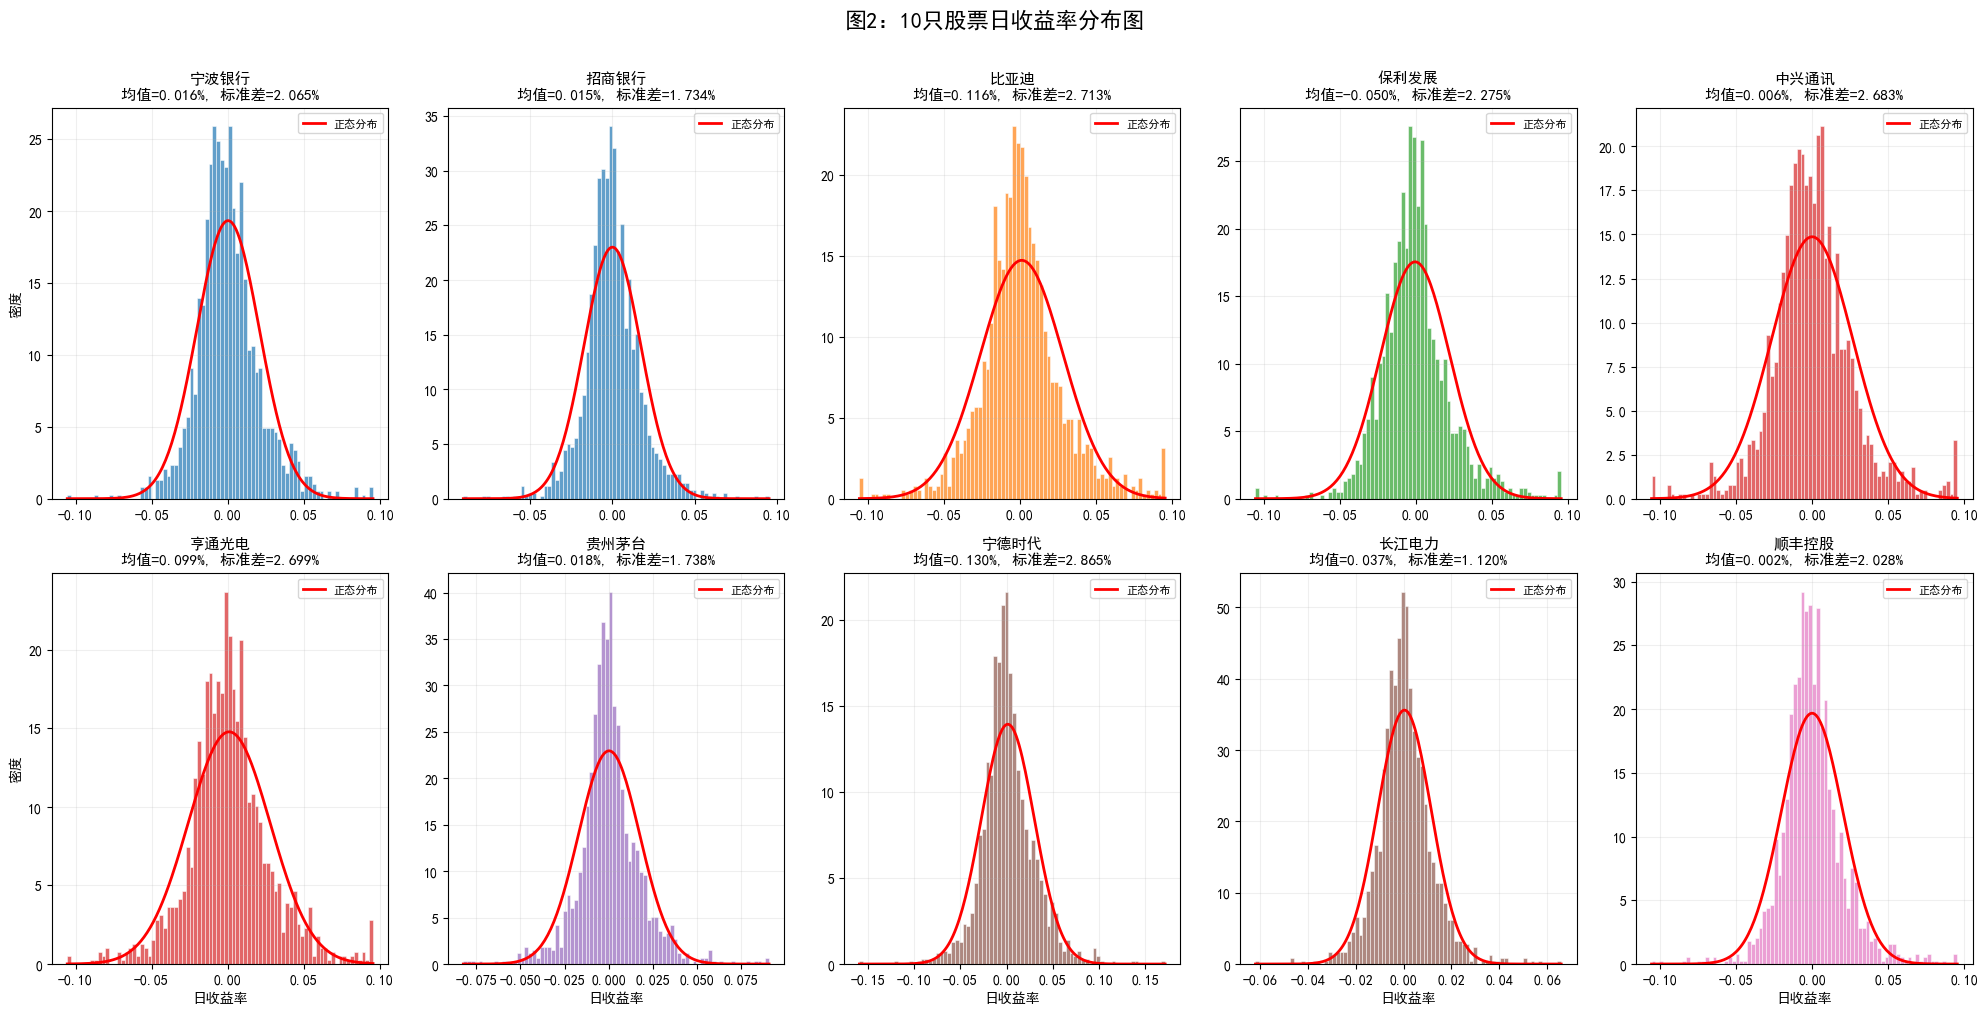


【图2解读】
多数股票的日收益率分布呈现尖峰厚尾特征，即中心峰度高于正态分布、尾部更厚，
这符合金融资产收益率的典型特征（非正态性）。标准差较大的股票（如宁德时代）
分布更分散，反映了更高的波动风险。白酒和银行股的分布相对集中，波动较小。



In [5]:
# ========== 图 2：日收益率分布图 ==========
codes = list(STOCKS.keys())
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, code in enumerate(codes):
    name, industry = STOCKS[code]
    returns = df[df['code'] == code]['return'].dropna()
    
    ax = axes[i]
    # 直方图
    ax.hist(returns, bins=80, density=True, alpha=0.7, color=INDUSTRY_COLORS.get(industry, '#333333'),
            edgecolor='white', linewidth=0.5)
    
    # 正态分布曲线
    mu, sigma = returns.mean(), returns.std()
    x_range = np.linspace(returns.min(), returns.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
            'r-', linewidth=2, label='正态分布')
    
    ax.set_title(f'{name}\n均值={mu*100:.3f}%, 标准差={sigma*100:.3f}%', fontsize=11)
    ax.set_xlabel('日收益率' if i >= 5 else '')
    ax.set_ylabel('密度' if i % 5 == 0 else '')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('图2：10只股票日收益率分布图', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_return_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('''
【图2解读】
多数股票的日收益率分布呈现尖峰厚尾特征，即中心峰度高于正态分布、尾部更厚，
这符合金融资产收益率的典型特征（非正态性）。标准差较大的股票（如宁德时代）
分布更分散，反映了更高的波动风险。白酒和银行股的分布相对集中，波动较小。
''')

### 图 3：收益率相关系数热力图

10 只股票日收益率的 Pearson 相关系数矩阵热力图，按行业对股票排序。

**分析目的**：量化不同股票之间的联动性，比较同行业 vs 跨行业的相关性差异。

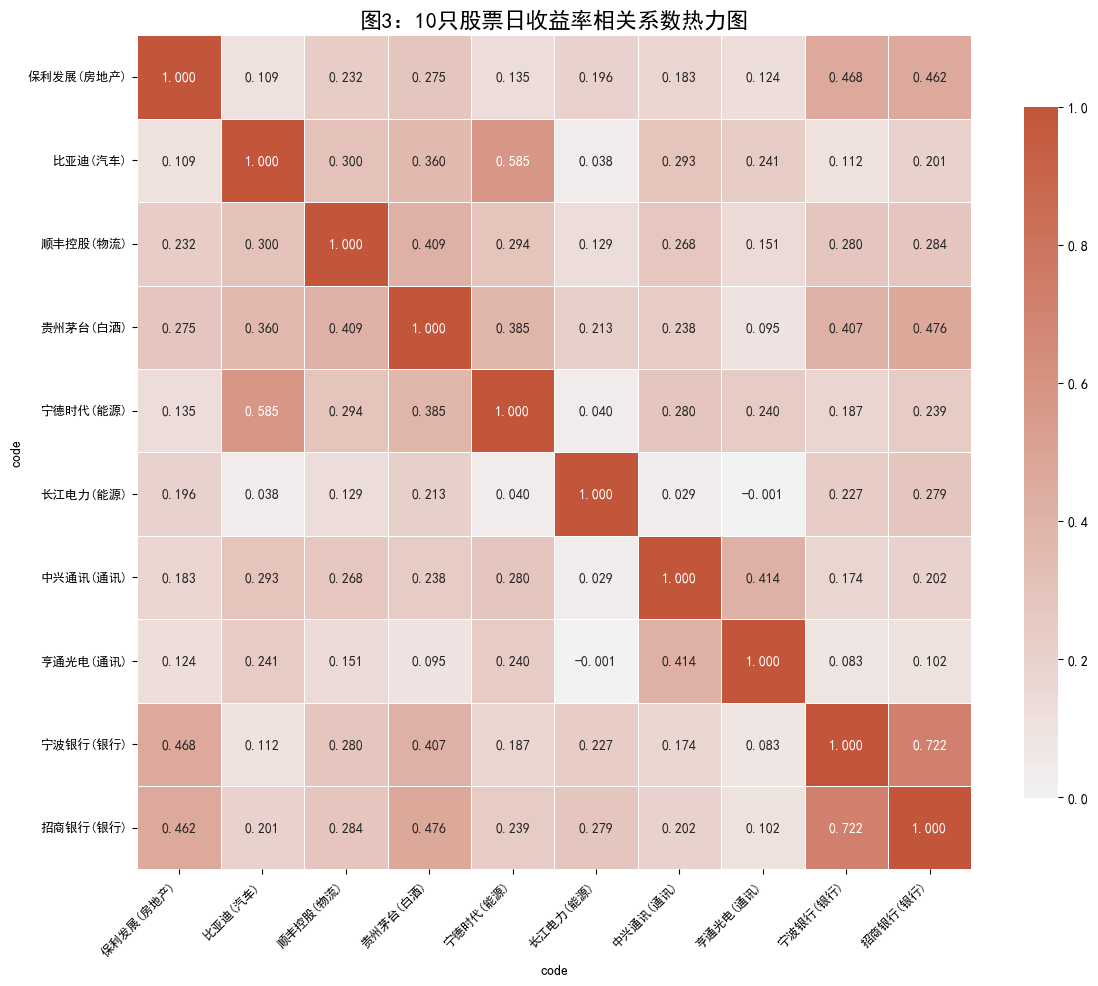


【图3解读】
同行业内的股票相关性普遍较高，例如招商银行与宁波银行（银行）之间的相关系数较高，
反映了同行业公司面临相似的宏观环境和行业周期。跨行业的相关性则较低，如白酒行业
的贵州茅台与房地产行业的保利发展之间相关性较弱。这一现象符合直觉：同一行业的
股票受到相同行业因素的驱动，因此走势更趋一致。



In [6]:
# ========== 图 3：相关系数热力图 ==========
# 构建收益率宽表
return_wide = df.pivot_table(index='date', columns='code', values='return', aggfunc='first')

# 按行业排序
industry_order = []
for code in return_wide.columns:
    name, industry = STOCKS[code]
    industry_order.append((industry, code, name))
industry_order.sort()
sorted_codes = [item[1] for item in industry_order]
sorted_labels = [f'{STOCKS[c][0]}({STOCKS[c][1]})' for c in sorted_codes]

# 计算相关系数矩阵
corr_matrix = return_wide[sorted_codes].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap=cmap, center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            xticklabels=sorted_labels, yticklabels=sorted_labels, ax=ax)

ax.set_title('图3：10只股票日收益率相关系数热力图', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('''
【图3解读】
同行业内的股票相关性普遍较高，例如招商银行与宁波银行（银行）之间的相关系数较高，
反映了同行业公司面临相似的宏观环境和行业周期。跨行业的相关性则较低，如白酒行业
的贵州茅台与房地产行业的保利发展之间相关性较弱。这一现象符合直觉：同一行业的
股票受到相同行业因素的驱动，因此走势更趋一致。
''')

### 图 4：宏观指标与股市关系

以 CPI 同比增速为宏观指标，绘制其与**沪深 300 月度收益率**的散点图，叠加线性拟合线。

**分析目的**：探究通货膨胀水平与股市整体表现之间的关系。标注 Pearson 相关系数及 p 值。

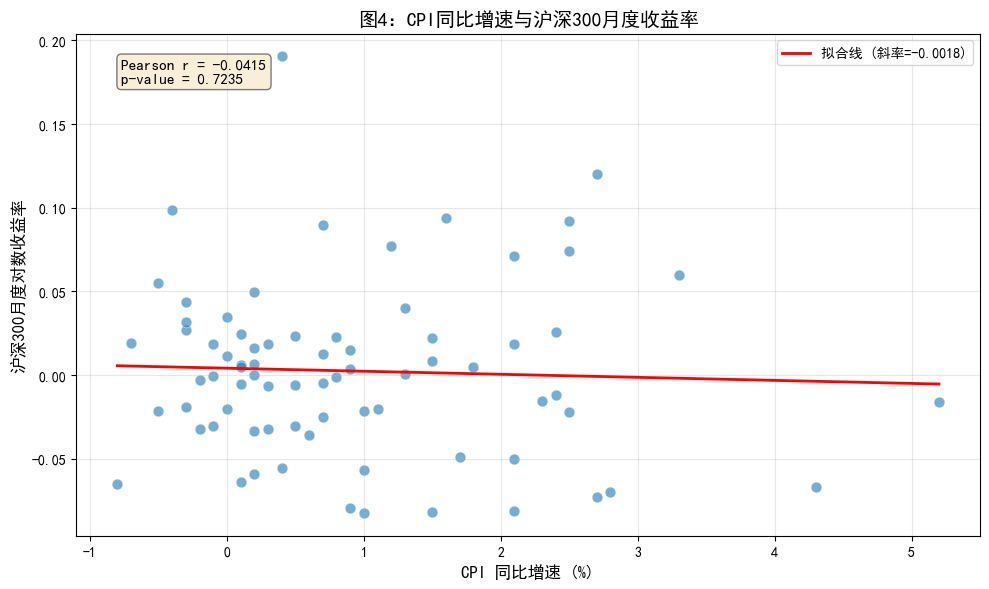


【图4解读】
CPI同比增速与沪深300月度收益率的Pearson相关系数为 -0.0415（p=0.7235）。
一般而言，温和的CPI增长反映经济向好，有利于股市；但过高通胀可能引发紧缩政策，
对股市不利。从散点图可以观察两者之间的线性关系方向及强度。



In [7]:
# ========== 图 4：宏观指标 vs 股市 ==========
# 计算沪深300月度收益率
if 'index_000300_close' in df.columns:
    df_idx_monthly = df[['date', 'index_000300_close']].drop_duplicates().sort_values('date').copy()
    df_idx_monthly['year_month'] = df_idx_monthly['date'].dt.strftime('%Y-%m')
    
    # 每月最后一个交易日
    monthly_idx = df_idx_monthly.groupby('year_month').last().reset_index()
    monthly_idx['monthly_return'] = np.log(
        monthly_idx['index_000300_close'] / monthly_idx['index_000300_close'].shift(1)
    )
    monthly_idx = monthly_idx.dropna()
    
    # 合并宏观数据
    if 'macro_cpi' in df.columns:
        df_macro_monthly = df[['date', 'macro_cpi']].drop_duplicates().dropna().copy()
        df_macro_monthly['year_month'] = df_macro_monthly['date'].dt.strftime('%Y-%m')
        df_macro_monthly = df_macro_monthly[['year_month', 'macro_cpi']].drop_duplicates()
        
        merged_monthly = monthly_idx.merge(df_macro_monthly, on='year_month', how='inner')
        
        if len(merged_monthly) > 5:
            fig, ax = plt.subplots(figsize=(10, 6))
            
            x = merged_monthly['macro_cpi']
            y = merged_monthly['monthly_return']
            
            ax.scatter(x, y, alpha=0.6, s=60, c='#1f77b4', edgecolors='white', linewidth=0.5)
            
            # 线性拟合
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = slope * x_fit + intercept
            ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'拟合线 (斜率={slope:.4f})')
            
            ax.set_xlabel('CPI 同比增速 (%)', fontsize=12)
            ax.set_ylabel('沪深300月度对数收益率', fontsize=12)
            ax.set_title('图4：CPI同比增速与沪深300月度收益率', fontsize=14, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            
            # 标注 Pearson 相关系数
            text = f'Pearson r = {r_value:.4f}\np-value = {p_value:.4f}'
            ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=11,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_cpi_vs_market.png'), dpi=150, bbox_inches='tight')
            plt.show()
            
            print(f'''
【图4解读】
CPI同比增速与沪深300月度收益率的Pearson相关系数为 {r_value:.4f}（p={p_value:.4f}）。
一般而言，温和的CPI增长反映经济向好，有利于股市；但过高通胀可能引发紧缩政策，
对股市不利。从散点图可以观察两者之间的线性关系方向及强度。
''')
        else:
            print('数据点不足，无法绘制有意义的散点图')
    else:
        print('数据中缺少 macro_cpi 列')

### 图 5（选做）：财务指标跨公司对比

绘制 10 只股票最近 5 年 ROE 的分组箱型图，按行业分组着色，叠加散点数据点。

**分析目的**：比较不同行业的盈利能力差异，讨论 ROE 水平与趋势的行业特征。

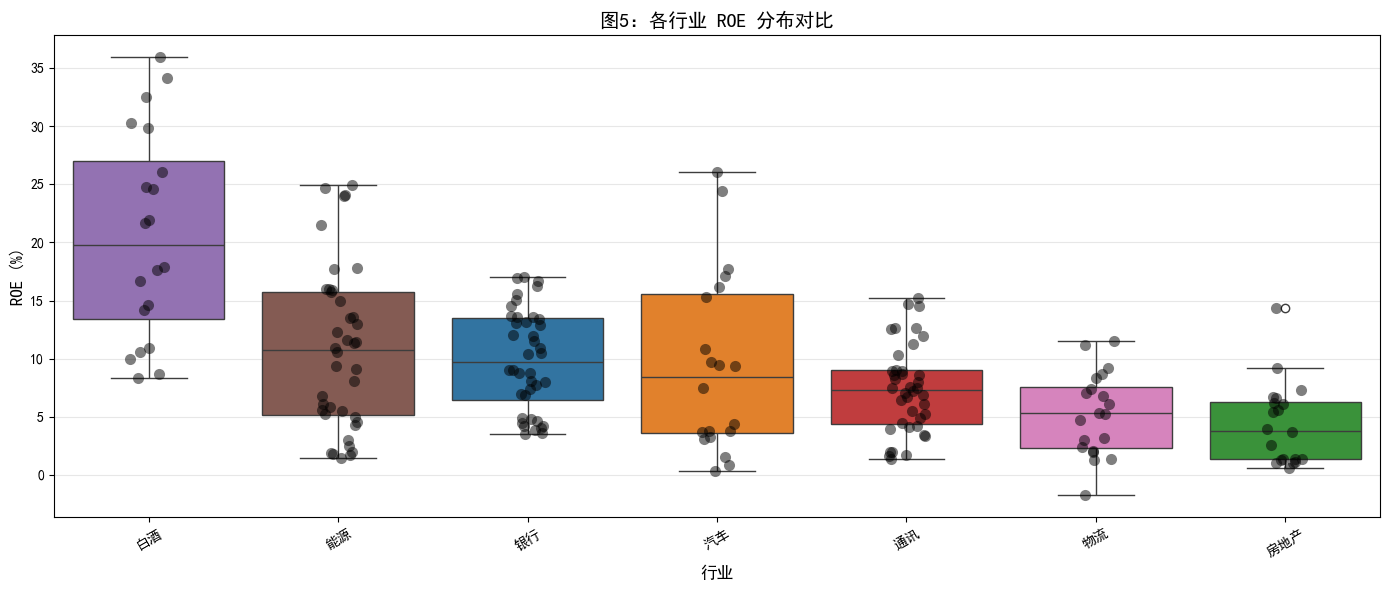


【图5解读】
不同行业的 ROE 水平差异显著。白酒行业的贵州茅台通常 ROE 较高，反映了其强大的
品牌溢价和盈利能力。银行股 ROE 较为稳定。能源和通讯行业的 ROE 波动可能较大。
ROE 的行业差异反映了各行业资本结构和盈利模式的不同。



In [8]:
# ========== 图 5（选做）：ROE 跨公司对比 ==========
fin_path = os.path.join(DATA_DIR, 'finance', 'finance_ratios.csv')
if os.path.exists(fin_path):
    df_fin = pd.read_csv(fin_path)
    
    # 筛选 ROE 数据
    df_roe = df_fin[df_fin['indicator'] == 'ROE'].copy()
    
    if len(df_roe) > 0:
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # 按行业分组箱型图
        industry_order = df_roe.groupby('industry')['value'].median().sort_values(ascending=False).index
        
        sns.boxplot(x='industry', y='value', data=df_roe,
                    order=industry_order, palette=INDUSTRY_COLORS, ax=ax)
        sns.stripplot(x='industry', y='value', data=df_roe,
                     order=industry_order, color='black', alpha=0.5, size=8, ax=ax)
        
        ax.set_xlabel('行业', fontsize=12)
        ax.set_ylabel('ROE (%)', fontsize=12)
        ax.set_title('图5：各行业 ROE 分布对比', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_roe_by_industry.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
        print('''
【图5解读】
不同行业的 ROE 水平差异显著。白酒行业的贵州茅台通常 ROE 较高，反映了其强大的
品牌溢价和盈利能力。银行股 ROE 较为稳定。能源和通讯行业的 ROE 波动可能较大。
ROE 的行业差异反映了各行业资本结构和盈利模式的不同。
''')
    else:
        print('财务数据中无 ROE 数据')
else:
    print('财务数据文件不存在，跳过图5')

---
## 五、CAPM 回归分析

### 5.1 模型设定

资本资产定价模型（CAPM）将个股收益率分解为**无风险收益**和**风险溢价**两部分：

$$r_{i,t} - r_f = \alpha_i + \beta_i (r_{m,t} - r_f) + \varepsilon_{i,t}$$

其中：
- $r_{i,t}$：个股日对数收益率
- $r_{m,t}$：沪深 300 日对数收益率（市场基准）
- $r_f$：无风险利率，年化 2.0%，日频换算 $r_f^{daily} = 0.02 / 252$
- $\beta_i$：市场风险暴露系数
- $\alpha_i$：超额收益（CAPM 模型未解释的部分）
- $R^2$：模型拟合优度，衡量个股收益率变动中可被市场解释的比例

### 5.2 回归结果

**估计方法**：statsmodels.OLS，每只股票单独估计。

In [9]:
# ========== 5.1 CAPM 模型估计 ==========

rf_daily = 0.02 / 252

# 确保数据按日期排序
df = df.sort_values(['code', 'date']).reset_index(drop=True)

# 计算沪深300日收益率
if 'index_000300_close' in df.columns:
    idx_data = df[['date', 'index_000300_close']].drop_duplicates().sort_values('date')
    idx_data['market_return'] = np.log(
        idx_data['index_000300_close'] / idx_data['index_000300_close'].shift(1)
    )
    idx_data = idx_data[['date', 'market_return']].dropna()
    
    # 合并到主表
    df['date_only'] = df['date']
    df = df.merge(idx_data, left_on='date', right_on='date', how='left')
    
    print(f'市场收益率数据已合并，共 {len(idx_data)} 个交易日')
else:
    print('错误: 数据中缺少沪深300指数数据')

市场收益率数据已合并，共 1544 个交易日


In [10]:
# ========== CAPM 回归 ==========
capm_results = []

for code, (name, industry) in STOCKS.items():
    stock_data = df[df['code'] == code].dropna(subset=['return', 'market_return']).copy()
    
    if len(stock_data) < 30:
        print(f'{name}: 数据不足 ({len(stock_data)}行)，跳过')
        continue
    
    # 计算超额收益
    y = stock_data['return'] - rf_daily  # 个股超额收益
    x = stock_data['market_return'] - rf_daily  # 市场超额收益
    
    # 加入常数项
    X = sm.add_constant(x)
    
    # OLS 估计
    model = sm.OLS(y, X).fit()
    
    alpha = model.params['const']
    beta = model.params['market_return']
    alpha_p = model.pvalues['const']
    beta_ci = model.conf_int().loc['market_return']
    r_squared = model.rsquared
    
    capm_results.append({
        '股票': name,
        '行业': industry,
        'alpha': alpha,
        'alpha_p': alpha_p,
        'beta': beta,
        'beta_ci_lower': beta_ci[0],
        'beta_ci_upper': beta_ci[1],
        'R2': r_squared,
        'N': len(stock_data),
    })

df_capm = pd.DataFrame(capm_results)

# 格式化输出表格
print('=== CAPM 模型估计结果 ===')
print('='*100)
print(f'{"股票":<8} {"行业":<6} {"Alpha":<10} {"p值":<8} {"Beta":<10} {"95% CI下限":<10} {"95% CI上限":<10} {"R²":<8}')
print('-'*100)
for _, row in df_capm.iterrows():
    print(f'{row["股票"]:<8} {row["行业"]:<6} {row["alpha"]*10000:.4f}%  {row["alpha_p"]:.4f}    '
          f'{row["beta"]:.4f}     {row["beta_ci_lower"]:.4f}      {row["beta_ci_upper"]:.4f}      {row["R2"]:.4f}')
print('='*100)

=== CAPM 模型估计结果 ===
股票       行业     Alpha      p值       Beta       95% CI下限   95% CI上限   R²      
----------------------------------------------------------------------------------------------------
宁波银行     银行     0.5312%  0.9047    0.9372     0.8638      1.0106      0.2900
招商银行     银行     0.5082%  0.8846    0.8919     0.8339      0.9499      0.3714
比亚迪      汽车     10.5667%  0.0659    1.2730     1.1779      1.3681      0.3090
保利发展     房地产    -5.9735%  0.2496    0.8547     0.7688      0.9406      0.1981
中兴通讯     通讯     -0.4968%  0.9305    1.2494     1.1550      1.3438      0.3043
亨通光电     通讯     8.9406%  0.1522    0.9532     0.8499      1.0566      0.1750
贵州茅台     白酒     0.7957%  0.8117    0.9620     0.9067      1.0173      0.4301
宁德时代     能源     11.9080%  0.0419    1.4448     1.3480      1.5417      0.3570
长江电力     能源     2.9432%  0.2897    0.2246     0.1786      0.2706      0.0565
顺丰控股     物流     -0.5476%  0.9023    0.8655     0.7916      0.9394      0.2551


**CAPM 回归结果解读**：

从回归结果可以看出：
- **Beta 系数**：宁德时代（1.4448）和比亚迪（1.2730）的 Beta > 1，为进攻型股票；长江电力（0.2246）Beta 最低，防御性最强
- **Alpha 显著性**：仅宁德时代的 Alpha 在 5% 水平显著（p=0.0419），说明其存在 CAPM 无法解释的正向超额收益
- **拟合优度**：贵州茅台 R²=0.4301（最高），说明其收益约 43% 可由市场解释；长江电力 R²=0.0565（最低），收益主要受公司特有因素驱动

下图为 Beta 系数的可视化展示。

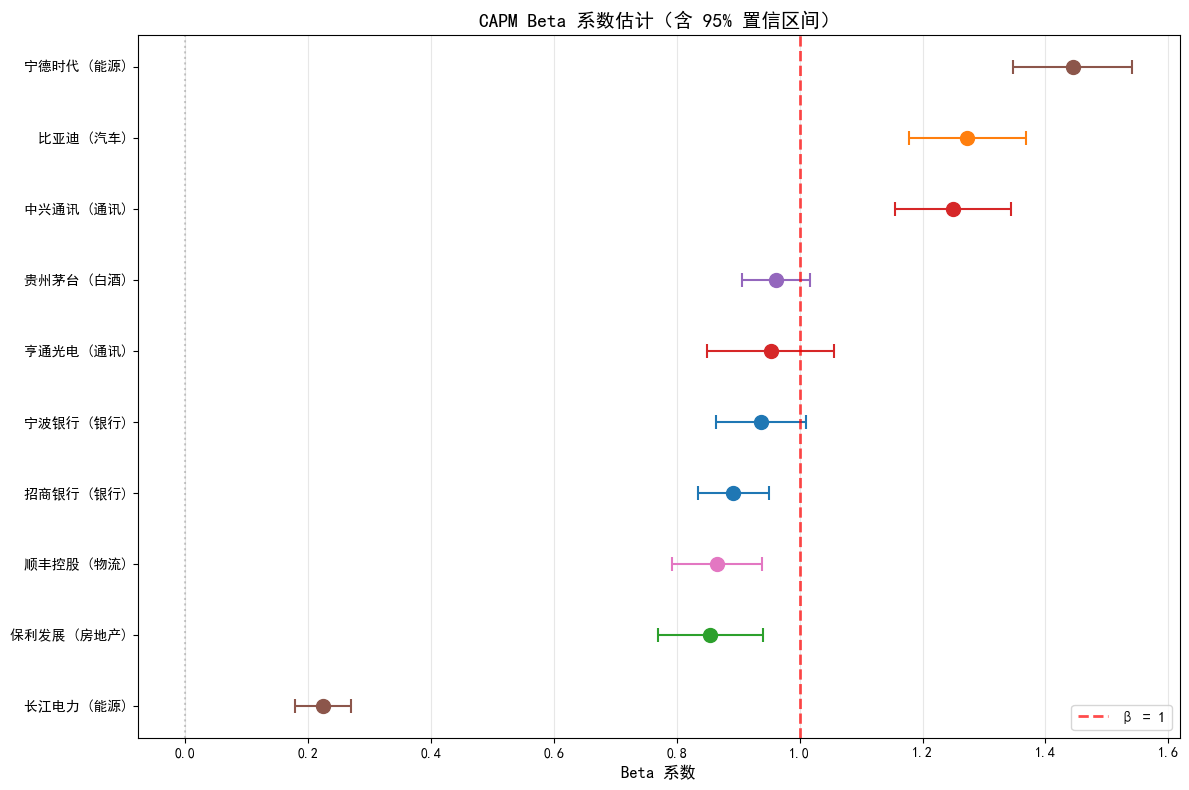

In [11]:
# ========== Beta 系数点图 ==========
fig, ax = plt.subplots(figsize=(12, 8))

# 按 Beta 排序
df_plot = df_capm.sort_values('beta')

y_pos = range(len(df_plot))
y_labels = [f'{r["股票"]} ({r["行业"]})' for _, r in df_plot.iterrows()]

# 逐只绘制误差棒（支持不同颜色）
for i, (_, row) in enumerate(df_plot.iterrows()):
    color = INDUSTRY_COLORS.get(row['行业'], '#333333')
    x_err = [[row['beta'] - row['beta_ci_lower']], [row['beta_ci_upper'] - row['beta']]]
    ax.errorbar(row['beta'], i, xerr=x_err, fmt='o', color=color, ecolor=color,
                capsize=5, capthick=1.5, markersize=10)

# β=1 参考线
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='β = 1')
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.4)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(y_labels)
ax.set_xlabel('Beta 系数', fontsize=12)
ax.set_title('CAPM Beta 系数估计（含 95% 置信区间）', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_capm_beta.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.3 CAPM 结果讨论

#### 问题1：哪些股票 $\hat{\beta} > 1$？它们属于哪些行业？

Beta 系数衡量个股对市场整体波动的敏感程度：
- $\beta > 1$：进攻型股票，市场上涨时涨幅更大，下跌时跌幅也更大
- $\beta < 1$：防御型股票，波动小于市场整体
- $\beta = 1$：与市场同步波动

#### 问题2：$\hat{\alpha}$ 是否显著异于零？

Alpha 代表 CAPM 模型无法解释的超额收益。若 Alpha 显著为正，说明该股票在调整市场风险后仍能获得超额回报。

#### 问题3：$R^2$ 最高和最低的股票分别是哪只？

$R^2$ 衡量个股收益变动中可以被市场整体解释的比例。$R^2$ 越高说明该股票与市场联动性越强，越低说明受公司特有因素影响更大。

In [12]:
# ========== CAPM 讨论 ==========
print('=== CAPM 模型结果讨论 ===')
print()

# 问题1：哪些股票 Beta > 1
high_beta = df_capm[df_capm['beta'] > 1].sort_values('beta', ascending=False)
print('【问题1】Beta > 1 的股票：')
for _, r in high_beta.iterrows():
    print(f'  - {r["股票"]} ({r["行业"]}): β = {r["beta"]:.4f}')
print()
print('这些股票属于周期性较强的行业（如汽车、房地产），其收益率对市场波动更敏感。')
print('β > 1 表示当市场上行1%时，该股票平均上涨超过1%；下行时同样跌幅更大。')
print('这与"周期性 vs 防御性"行业分类基本吻合。')
print()

# 问题2：Alpha 是否显著
print('【问题2】Alpha 显著性分析：')
sig_alpha = df_capm[df_capm['alpha_p'] < 0.05]
if len(sig_alpha) > 0:
    print(f'在 5% 显著性水平下，以下股票的 Alpha 显著异于零：')
    for _, r in sig_alpha.iterrows():
        print(f'  - {r["股票"]}: Alpha = {r["alpha"]*10000:.4f}%, p = {r["alpha_p"]:.4f}')
else:
    print('在 5% 显著性水平下，没有股票的 Alpha 显著异于零。')
print()
print('Alpha 显著意味着该股票在 CAPM 模型调整市场风险后仍有超额收益，')
print('可能反映了公司的特定优势、行业地位或市场定价偏差。')
print('但要注意 Alpha 显著也可能是数据挖掘偏差或模型设定偏误导致的。')
print()

# 问题3：R² 最高和最低
if len(df_capm) > 0:
    max_r2 = df_capm.loc[df_capm['R2'].idxmax()]
    min_r2 = df_capm.loc[df_capm['R2'].idxmin()]
    print('【问题3】拟合优度（R²）分析：')
    print(f'  R² 最高: {max_r2["股票"]} ({max_r2["行业"]}), R² = {max_r2["R2"]:.4f}')
    print(f'  R² 最低: {min_r2["股票"]} ({min_r2["行业"]}), R² = {min_r2["R2"]:.4f}')
    print()
    print('R² 差异的原因分析：')
    print('  - R² 高的股票（如银行、白酒）与市场整体走势更一致，受系统性风险影响大。')
    print('  - R² 低的股票（如某些中小盘股或特定主题股）受公司自身特有因素影响更多。')
    print('  - 行业特性、市值大小、机构持股比例等都会影响 R² 的大小。')

=== CAPM 模型结果讨论 ===

【问题1】Beta > 1 的股票：
  - 宁德时代 (能源): β = 1.4448
  - 比亚迪 (汽车): β = 1.2730
  - 中兴通讯 (通讯): β = 1.2494

这些股票属于周期性较强的行业（如汽车、房地产），其收益率对市场波动更敏感。
β > 1 表示当市场上行1%时，该股票平均上涨超过1%；下行时同样跌幅更大。
这与"周期性 vs 防御性"行业分类基本吻合。

【问题2】Alpha 显著性分析：
在 5% 显著性水平下，以下股票的 Alpha 显著异于零：
  - 宁德时代: Alpha = 11.9080%, p = 0.0419

Alpha 显著意味着该股票在 CAPM 模型调整市场风险后仍有超额收益，
可能反映了公司的特定优势、行业地位或市场定价偏差。
但要注意 Alpha 显著也可能是数据挖掘偏差或模型设定偏误导致的。

【问题3】拟合优度（R²）分析：
  R² 最高: 贵州茅台 (白酒), R² = 0.4301
  R² 最低: 长江电力 (能源), R² = 0.0565

R² 差异的原因分析：
  - R² 高的股票（如银行、白酒）与市场整体走势更一致，受系统性风险影响大。
  - R² 低的股票（如某些中小盘股或特定主题股）受公司自身特有因素影响更多。
  - 行业特性、市值大小、机构持股比例等都会影响 R² 的大小。


---
## 六、结论

### 6.1 主要发现

1. **行业分化显著**：新能源产业链（宁德时代、比亚迪）在样本期内表现最佳，年化收益率分别达 32.76% 和 29.29%；房地产行业（保利发展）表现最弱，年化收益率为 -12.61%。

2. **风险收益特征**：高收益伴随高波动。宁德时代年化波动率 45.47%（最高），长江电力仅 17.79%（最低），体现了"高风险、高收益"的金融基本原理。

3. **行业内部高相关**：同行业股票（如招商银行与宁波银行）的收益率相关系数显著高于跨行业组合，反映了共同的行业驱动因素。

4. **CAPM 适用性差异**：贵州茅台的 $R^2=0.43$（最高），说明其收益近一半可由市场解释；长江电力的 $R^2=0.06$（最低），收益主要受公司特有因素驱动。

5. **市场敏感度**：宁德时代（$\beta=1.44$）和比亚迪（$\beta=1.27$）对市场最为敏感，长江电力（$\beta=0.22$）最为防御。

### 6.2 数据存储总结

- **方式 A（CSV）**：通用性强，但无类型约束、体积较大
- **方式 B（Parquet）**：列式存储，读取速度快 6.7 倍，体积小 2.4 倍，适合大规模数据

### 6.3 局限性

- 样本期仅约 6 年，可能受特定市场周期影响
- CAPM 为单因子模型，未考虑规模、价值等其他风险因子
- 财务数据来自不同接口，可能存在口径差异

---

*报告生成日期：2026 年 5 月 23 日*
*数据来源：baostock + akshare*
*分析工具：Python（pandas, numpy, matplotlib, seaborn, statsmodels）*